<a href="https://colab.research.google.com/github/hemagayathri17-ai/SCT_ML_1_New/blob/main/data_cleaning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ORIGINAL DATA INSPECTION
First 5 rows:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Missing values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class    

/tmp/ipykernel_2723/2155693405.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
/tmp/ipykernel_2723/2155693405.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

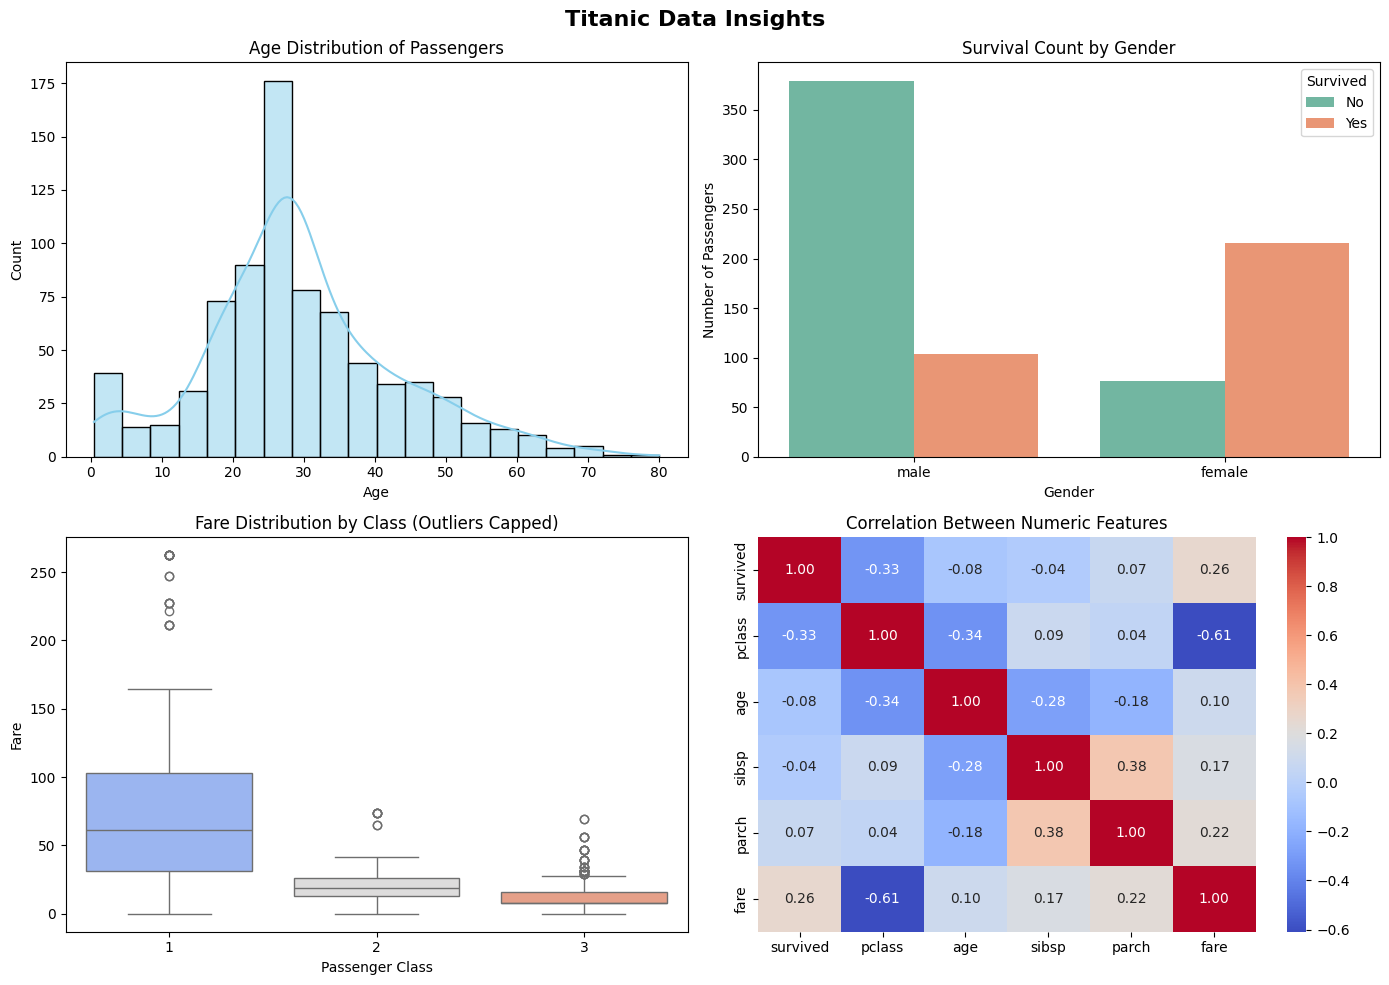


PROJECT SUMMARY (Storytelling)
Raw data issues:
- Age had 20% missing values.
- Embarked had 2 missing values.
- Fare had extreme outliers.
- Deck column was mostly empty.

Cleaning steps applied:
- Filled missing ages with median.
- Filled embarked with mode.
- Dropped deck column.
- Removed duplicates.
- Capped fare outliers at 1st and 99th percentiles.

Key insights from visualisations:
- Most passengers were aged 20-40.
- Females had significantly higher survival rates than males.
- 1st class passengers paid much higher fares.
- Fare moderately correlated with survival.

Conclusion:
Class and gender were strong predictors of survival on the Titanic.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
df = sns.load_dataset('titanic')
print("="*50)
print("ORIGINAL DATA INSPECTION")
print("="*50)
print("First 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# 3. Clean the data
df_clean = df.copy()

# Handle missing values
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)
if 'deck' in df_clean.columns:
    df_clean.drop('deck', axis=1, inplace=True)

# Remove duplicates
df_clean.drop_duplicates(inplace=True)

# Cap outliers in 'fare'
q_low = df_clean['fare'].quantile(0.01)
q_high = df_clean['fare'].quantile(0.99)
df_clean['fare'] = df_clean['fare'].clip(q_low, q_high)

print("\n" + "="*50)
print("AFTER CLEANING")
print("="*50)
print("Missing values left:\n", df_clean.isnull().sum())
print("New shape:", df_clean.shape)

# 4. Create visualisations (4 plots)
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic Data Insights', fontsize=16, fontweight='bold')

# Plot 1: Age distribution
sns.histplot(df_clean['age'], bins=20, kde=True, color='skyblue', ax=axes[0,0])
axes[0,0].set_title('Age Distribution of Passengers')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Plot 2: Survival by gender
sns.countplot(data=df_clean, x='sex', hue='survived', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Survival Count by Gender')
axes[0,1].set_xlabel('Gender')
axes[0,1].set_ylabel('Number of Passengers')
axes[0,1].legend(title='Survived', labels=['No', 'Yes'])

# Plot 3: Fare by class (boxplot)
sns.boxplot(data=df_clean, x='pclass', y='fare', palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Fare Distribution by Class (Outliers Capped)')
axes[1,0].set_xlabel('Passenger Class')
axes[1,0].set_ylabel('Fare')

# Plot 4: Correlation heatmap
numeric_df = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Correlation Between Numeric Features')

plt.tight_layout()
plt.show()

# 5. Print summary / story
print("\n" + "="*50)
print("PROJECT SUMMARY (Storytelling)")
print("="*50)
print("Raw data issues:")
print("- Age had 20% missing values.")
print("- Embarked had 2 missing values.")
print("- Fare had extreme outliers.")
print("- Deck column was mostly empty.")
print("\nCleaning steps applied:")
print("- Filled missing ages with median.")
print("- Filled embarked with mode.")
print("- Dropped deck column.")
print("- Removed duplicates.")
print("- Capped fare outliers at 1st and 99th percentiles.")
print("\nKey insights from visualisations:")
print("- Most passengers were aged 20-40.")
print("- Females had significantly higher survival rates than males.")
print("- 1st class passengers paid much higher fares.")
print("- Fare moderately correlated with survival.")
print("\nConclusion:")
print("Class and gender were strong predictors of survival on the Titanic.")